# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_ta as ta
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", None)

print("✅ Libraries loaded!")
print(f"📊 pandas-ta version: {ta.version}")

✅ Libraries loaded!
📊 pandas-ta version: 0.4.71b0


# Load all stock data

In [2]:
# Load all 6 stocks
stocks = ["AAPL", "AMZN", "GOOG", "META", "MSFT", "NVDA"]
stock_data = {}

for stock in stocks:
    df = pd.read_csv(f"../data/{stock}.csv")
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    stock_data[stock] = df
    print(f"✅ {stock}: {len(df):,} rows | {df['Date'].min().date()} to {df['Date'].max().date()}")

print(f"\n🎉 All stocks loaded!")

✅ AAPL: 3,774 rows | 2009-01-02 to 2023-12-29
✅ AMZN: 3,774 rows | 2009-01-02 to 2023-12-29
✅ GOOG: 3,774 rows | 2009-01-02 to 2023-12-29
✅ META: 2,923 rows | 2012-05-18 to 2023-12-29
✅ MSFT: 3,774 rows | 2009-01-02 to 2023-12-29
✅ NVDA: 3,774 rows | 2009-01-02 to 2023-12-29

🎉 All stocks loaded!


# Calculate technical indicators

In [3]:
# Calculate MA, RSI, MACD for all stocks
for stock, df in stock_data.items():

    # Moving Averages
    df["MA20"]  = ta.sma(df["Close"], length=20)
    df["MA50"]  = ta.sma(df["Close"], length=50)
    df["MA200"] = ta.sma(df["Close"], length=200)

    # RSI
    df["RSI"] = ta.rsi(df["Close"], length=14)

    # MACD
    macd = ta.macd(df["Close"], fast=12, slow=26, signal=9)
    df["MACD"]        = macd["MACD_12_26_9"]
    df["MACD_Signal"] = macd["MACDs_12_26_9"]
    df["MACD_Hist"]   = macd["MACDh_12_26_9"]

    # Daily Returns
    df["Daily_Return"] = df["Close"].pct_change() * 100

    # Volatility (20 day rolling std)
    df["Volatility"] = df["Daily_Return"].rolling(20).std()

    stock_data[stock] = df
    print(f"✅ {stock} indicators calculated!")

print("\n🎉 All technical indicators ready!")

✅ AAPL indicators calculated!
✅ AMZN indicators calculated!
✅ GOOG indicators calculated!
✅ META indicators calculated!
✅ MSFT indicators calculated!
✅ NVDA indicators calculated!

🎉 All technical indicators ready!


# Visualize NVDA with all indicators

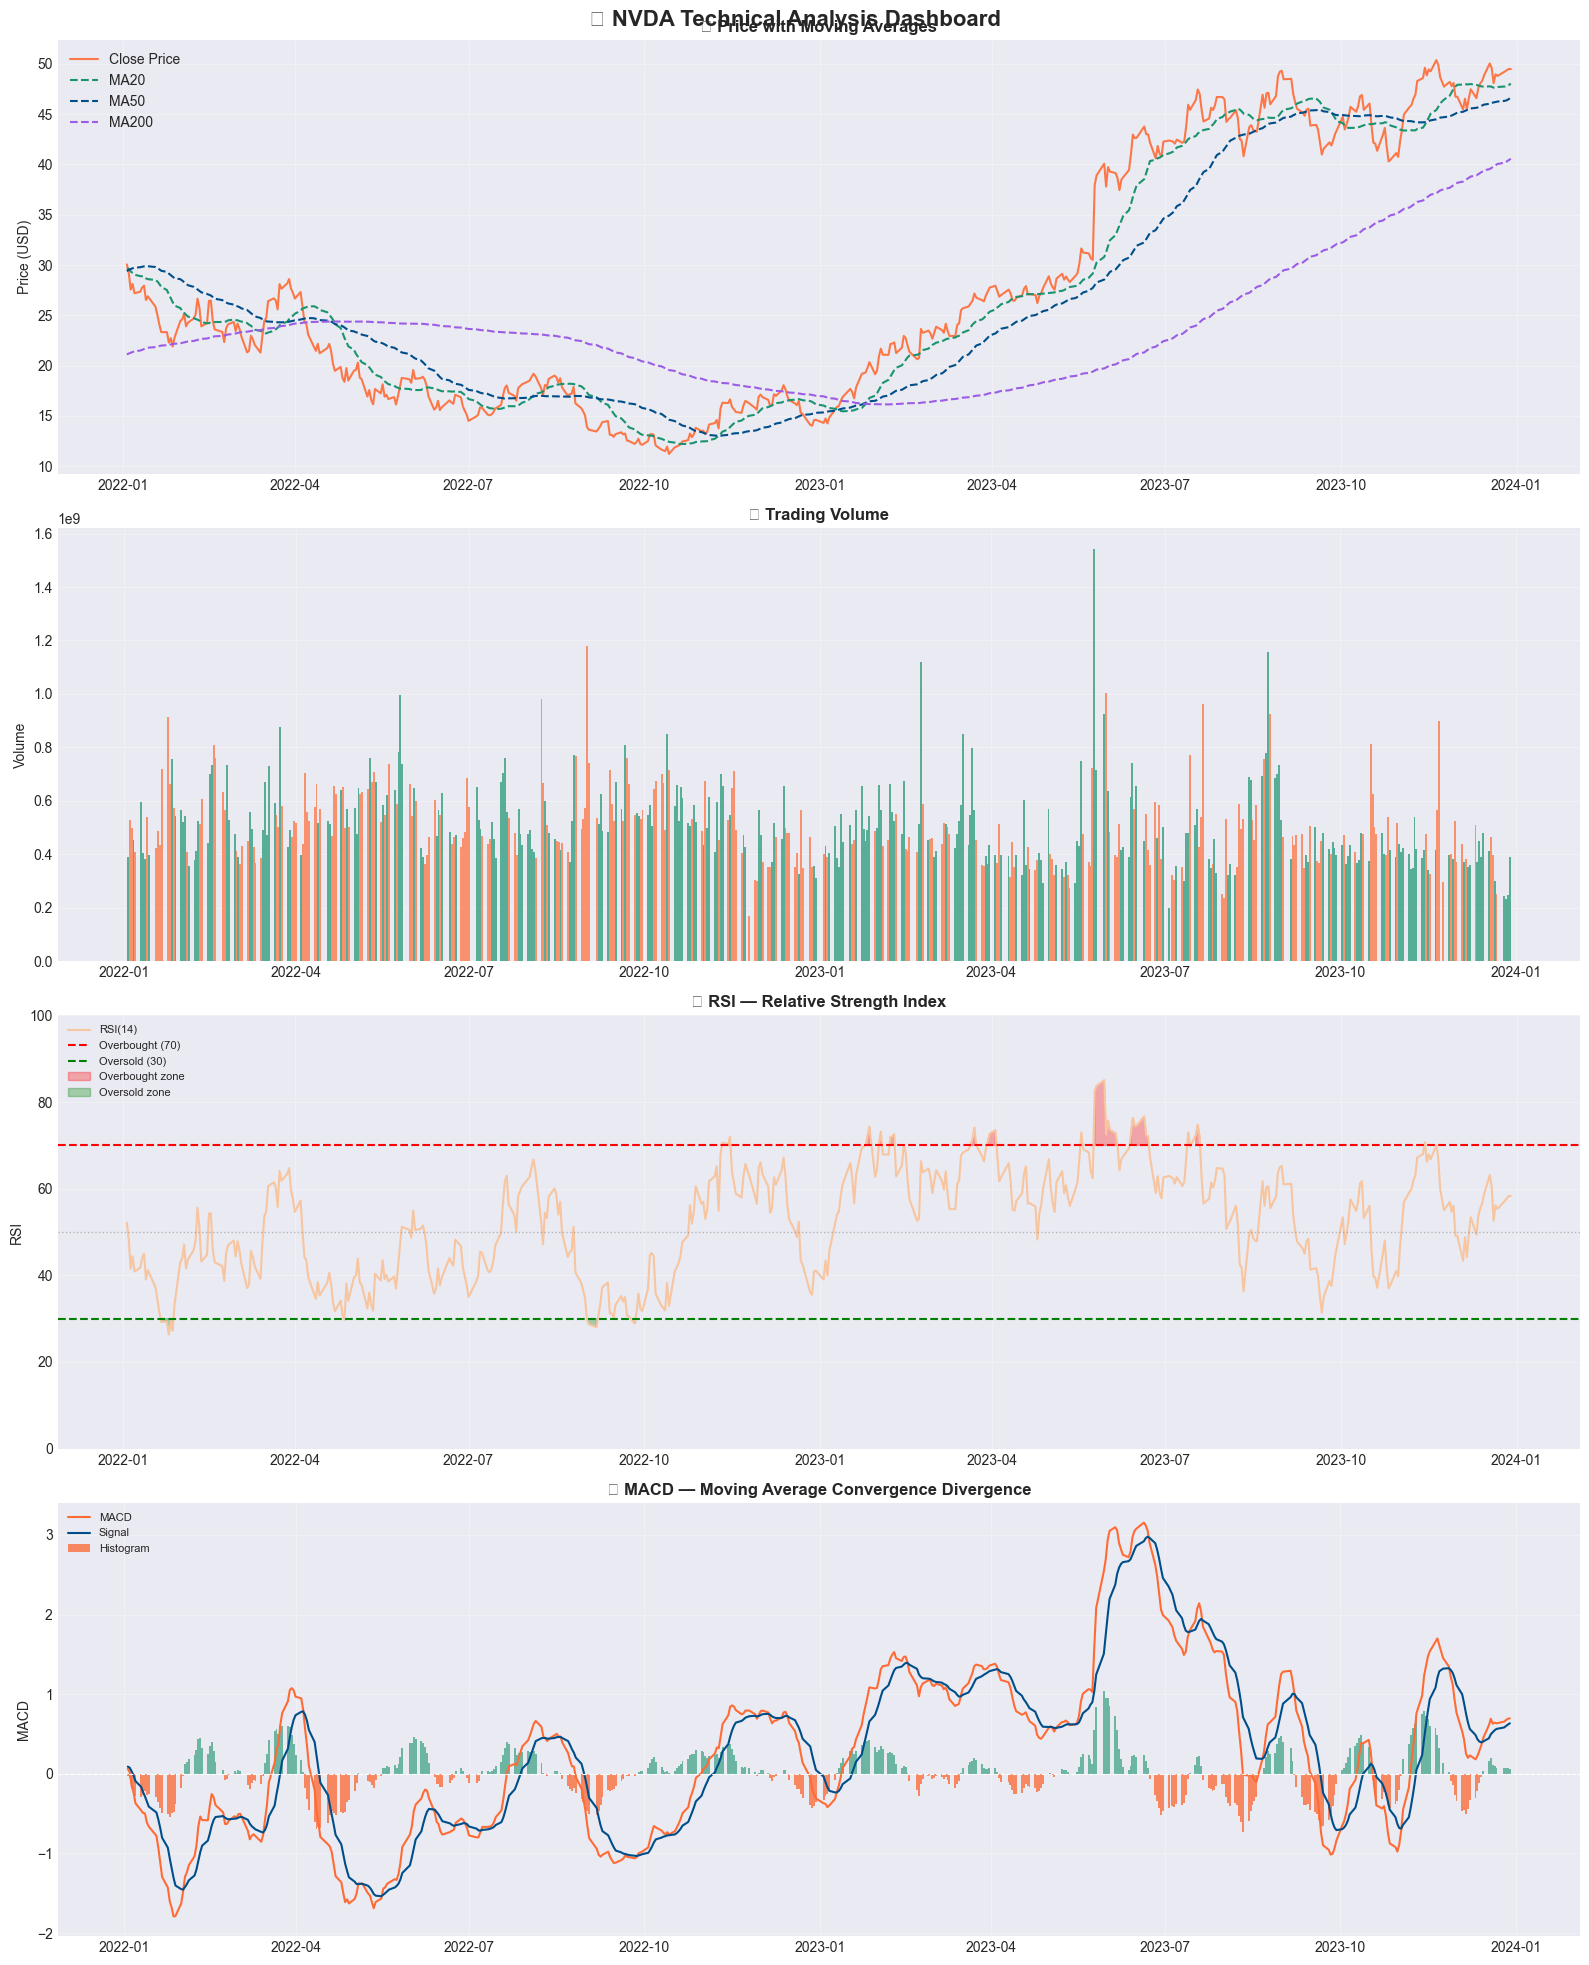

✅ NVDA technical analysis chart saved!


In [4]:
# Let's visualize NVDA as our main example
stock = "NVDA"
df = stock_data[stock].copy()

# Use last 2 years for clarity
df = df[df["Date"] >= "2022-01-01"].copy()

fig, axes = plt.subplots(4, 1, figsize=(16, 20))
fig.suptitle(f"📈 {stock} Technical Analysis Dashboard",
             fontsize=16, fontweight="bold", y=0.98)

# Plot 1 — Price with Moving Averages
ax1 = axes[0]
ax1.plot(df["Date"], df["Close"],
         color="#FF6B35", linewidth=1.5, label="Close Price", alpha=0.9)
ax1.plot(df["Date"], df["MA20"],
         color="#1A936F", linewidth=1.5, label="MA20", linestyle="--")
ax1.plot(df["Date"], df["MA50"],
         color="#004E89", linewidth=1.5, label="MA50", linestyle="--")
ax1.plot(df["Date"], df["MA200"],
         color="#9B5DE5", linewidth=1.5, label="MA200", linestyle="--")
ax1.set_title("💰 Price with Moving Averages", fontweight="bold")
ax1.set_ylabel("Price (USD)")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# Plot 2 — Volume
ax2 = axes[1]
colors_vol = ["#1A936F" if r >= 0 else "#FF6B35"
              for r in df["Daily_Return"]]
ax2.bar(df["Date"], df["Volume"],
        color=colors_vol, alpha=0.7, width=1)
ax2.set_title("📊 Trading Volume", fontweight="bold")
ax2.set_ylabel("Volume")
ax2.grid(True, alpha=0.3)

# Plot 3 — RSI
ax3 = axes[2]
ax3.plot(df["Date"], df["RSI"],
         color="#F7C59F", linewidth=1.5, label="RSI(14)")
ax3.axhline(y=70, color="red", linestyle="--",
            linewidth=1.5, label="Overbought (70)")
ax3.axhline(y=30, color="green", linestyle="--",
            linewidth=1.5, label="Oversold (30)")
ax3.axhline(y=50, color="gray", linestyle=":",
            linewidth=1, alpha=0.5)
ax3.fill_between(df["Date"], df["RSI"], 70,
                 where=(df["RSI"] >= 70),
                 color="red", alpha=0.3, label="Overbought zone")
ax3.fill_between(df["Date"], df["RSI"], 30,
                 where=(df["RSI"] <= 30),
                 color="green", alpha=0.3, label="Oversold zone")
ax3.set_title("📉 RSI — Relative Strength Index", fontweight="bold")
ax3.set_ylabel("RSI")
ax3.set_ylim(0, 100)
ax3.legend(loc="upper left", fontsize=8)
ax3.grid(True, alpha=0.3)

# Plot 4 — MACD
ax4 = axes[3]
ax4.plot(df["Date"], df["MACD"],
         color="#FF6B35", linewidth=1.5, label="MACD")
ax4.plot(df["Date"], df["MACD_Signal"],
         color="#004E89", linewidth=1.5, label="Signal")
colors_hist = ["#1A936F" if v >= 0 else "#FF4500"
               for v in df["MACD_Hist"].fillna(0)]
ax4.bar(df["Date"], df["MACD_Hist"],
        color=colors_hist, alpha=0.6, width=1, label="Histogram")
ax4.axhline(y=0, color="white", linewidth=0.8, linestyle="--")
ax4.set_title("📊 MACD — Moving Average Convergence Divergence",
              fontweight="bold")
ax4.set_ylabel("MACD")
ax4.legend(loc="upper left", fontsize=8)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/nvda_technical_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ NVDA technical analysis chart saved!")

# Compare all stocks performance

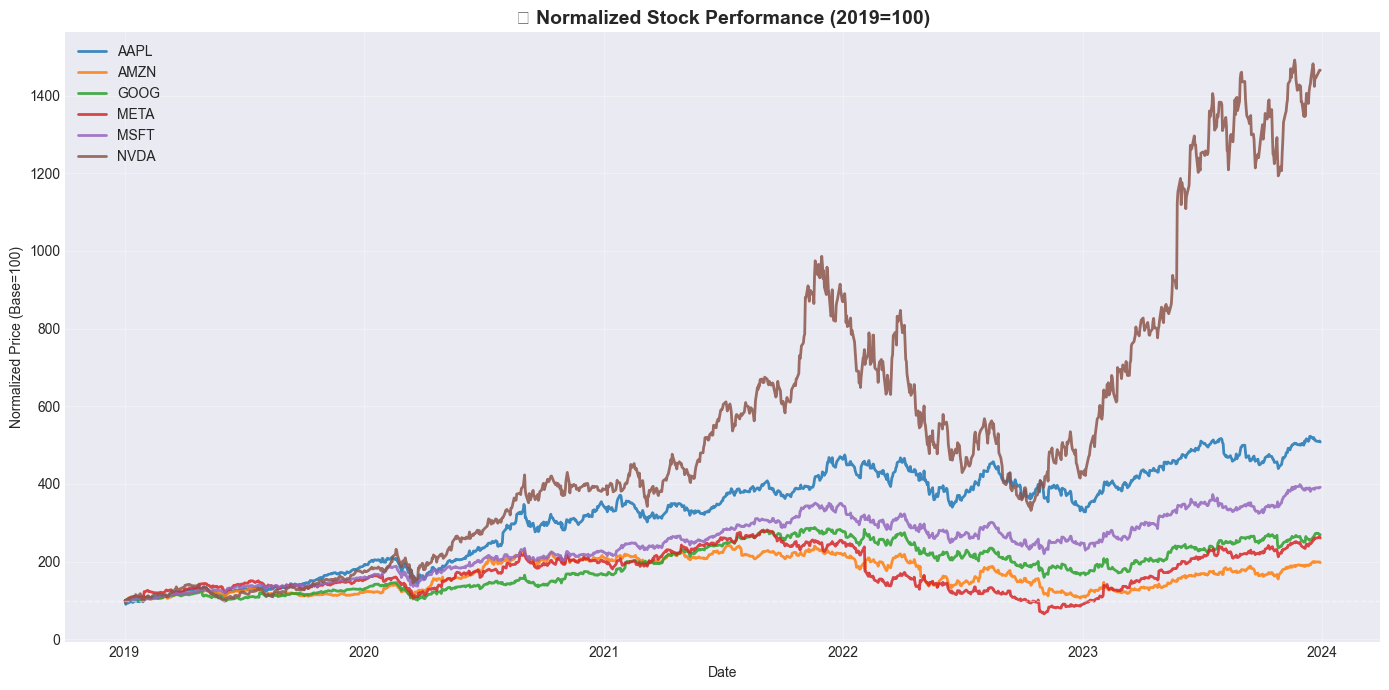

✅ Stock comparison chart saved!


In [5]:
plt.figure(figsize=(14, 7))

# Normalize prices to 100 for fair comparison
for stock, df in stock_data.items():
    # Use from 2019 onwards
    df_plot = df[df["Date"] >= "2019-01-01"].copy()
    # Normalize — start at 100
    normalized = (df_plot["Close"] / df_plot["Close"].iloc[0]) * 100
    plt.plot(df_plot["Date"], normalized,
             linewidth=2, label=stock, alpha=0.85)

plt.title("📈 Normalized Stock Performance (2019=100)",
          fontsize=14, fontweight="bold")
plt.ylabel("Normalized Price (Base=100)")
plt.xlabel("Date")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=100, color="white", linestyle="--",
            linewidth=1, alpha=0.5)
plt.tight_layout()
plt.savefig("../data/stock_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Stock comparison chart saved!")

# RSI summary for all stocks

In [6]:
print("=== 📊 CURRENT TECHNICAL SUMMARY ===\n")
print(f"{'Stock':<8} {'Price':>10} {'MA20':>10} {'MA50':>10} {'RSI':>8} {'Signal':>12}")
print("-" * 60)

for stock, df in stock_data.items():
    latest = df.iloc[-1]
    price  = latest["Close"]
    ma20   = latest["MA20"]
    ma50   = latest["MA50"]
    rsi    = latest["RSI"]

    # Signal
    if rsi > 70:
        signal = "🔴 Overbought"
    elif rsi < 30:
        signal = "🟢 Oversold"
    elif price > ma20 > ma50:
        signal = "📈 Bullish"
    elif price < ma20 < ma50:
        signal = "📉 Bearish"
    else:
        signal = "⚪ Neutral"

    print(f"{stock:<8} ${price:>9.2f} ${ma20:>9.2f} "
          f"${ma50:>9.2f} {rsi:>7.1f} {signal}")

=== 📊 CURRENT TECHNICAL SUMMARY ===

Stock         Price       MA20       MA50      RSI       Signal
------------------------------------------------------------
AAPL     $   190.73 $   192.49 $   184.81    51.1 ⚪ Neutral
AMZN     $   151.94 $   149.82 $   143.05    59.0 📈 Bullish
GOOG     $   139.97 $   135.98 $   134.06    59.3 📈 Bullish
META     $   351.79 $   336.87 $   326.26    64.3 📈 Bullish
MSFT     $   371.21 $   367.79 $   358.64    58.0 📈 Bullish
NVDA     $    49.50 $    48.05 $    46.66    58.3 📈 Bullish
